In [ ]:
# from PIL import Image, PngImagePlugin
# from pathlib import Path

# PngImagePlugin.MAX_TEXT_CHUNK = 100 * (1024**2)  # raise limit so we can open them

# folder = Path("/figures/laion_5k_generated_pt")

# for img_path in folder.glob("*.png"):
#     try:
#         img = Image.open(img_path).convert("RGB")
#         img.save(img_path, format="PNG", icc_profile=None)
#     except Exception as e:
#         print(f"Failed {img_path.name}: {e}")

# print("Done")

In [2]:
import pandas as pd

df = pd.read_csv("laion_5k_prompts.csv")

df[["url"]].to_csv("laion_5k_urls.csv", index=False)
df[["text"]].to_csv("laion_5k_texts.csv", index=False)

print(f"Saved {len(df)} urls and {len(df)} texts")

Saved 5000 urls and 5000 texts


In [1]:
import pandas as pd


df = pd.read_csv("laion_5k_prompts.csv")
print(f"Rows: {len(df)}")
print(df.columns.tolist())
print(df.head())

Rows: 5000
['url', 'text']
                                                 url  \
0  https://i.ebayimg.com/images/g/iiIAAOSw0j9ZU6t...   
1  https://www.vector-eps.com/wp-content/gallery/...   
2   https://bikes.rim.de/bikid-69184-800-800-0-0.jpg   
3  https://images.complex.com/complex/images/c_li...   
4  https://lmr.net.au/wp-content/uploads/2013/12/...   

                                                text  
0  2 pcs 6 9 * 7 1 mm green plastic bobbin wire c...  
1  license you can use spring labels vector desig...  
2                               puky - racer angebot  
3      the 2 5 best actresses who never won an oscar  
4  roofing gold coast , colorbond roofing gold co...  


In [3]:
import requests
from pathlib import Path
import pandas as pd
from PIL import Image
from io import BytesIO

real_dir = Path("/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/figures/laion_5k_real")
real_dir.mkdir(exist_ok=True)

df = pd.read_csv("laion_5k_urls.csv")
failed_indices = []
saved = len(list(real_dir.glob("*.png")))  # count already saved

for idx, row in df.iterrows():
    if saved >= 5000:
        break
    img_path = real_dir / f"{idx:05d}.png"
    if img_path.exists():
        continue
    try:
        r = requests.get(row["url"], timeout=5)
        r.raise_for_status()
        img = Image.open(BytesIO(r.content)).convert("RGB")
        img.save(img_path, icc_profile=None)
        saved += 1
        if saved % 100 == 0:
            print(f"  saved {saved}/5000")
    except Exception as e:
        failed_indices.append(idx)
        print(f"  [{idx}] failed: {e}")

print(f"\nDone. {saved}/5000 images saved.")
print(f"Failed indices ({len(failed_indices)}): {failed_indices}")

  [1] failed: 403 Client Error: Forbidden for url: https://www.vector-eps.com/
  [3] failed: 400 Client Error: Bad Request for url: https://images.complex.com/complex/images/c_limit,w_680/fl_lossy,pg_1,q_auto/uacvjmflocled29hoabn/the-25-best-actresses-whove-never-won-an-oscar
  [4] failed: 404 Client Error: Not Found for url: https://lmr.net.au/wp-content/uploads/2013/12/bond-191-225x300.jpg
  [5] failed: HTTPSConnectionPool(host='371814.smushcdn.com', port=443): Max retries exceeded with url: /1419648/wp-content/uploads/2018/08/fenestration-calculator-fenca.png?lossy=1&strip=1&webp=1 (Caused by NameResolutionError("HTTPSConnection(host='371814.smushcdn.com', port=443): Failed to resolve '371814.smushcdn.com' ([Errno -2] Name or service not known)"))
  [10] failed: 403 Client Error: Forbidden for url: https://ih0.redbubble.net/image.235734919.9407/pp,220x200-pad,220x200,ffffff.u3.jpg
  [12] failed: HTTPSConnectionPool(host='data.whicdn.com', port=443): Max retries exceeded with url: /i

In [ ]:
# saving failed indices txt

import json

with open("failed_indices.txt", "w") as f:
    json.dump(failed_indices, f)
print(f"Failed indices saved to failed_indices.txt")

import json

with open("failed_indices.txt") as f:
    failed_indices = json.load(f)

Failed indices saved to failed_indices.txt


In [2]:
# from datasets import load_dataset
# import pandas as pd

# # LAION Aesthetics V2 (most commonly cited)
# ds = load_dataset("laion/aesthetics_v2_4.5", split="train", streaming=True)

# # Take first 5000 entries
# subset = []
# for i, item in enumerate(ds):
#     if i >= 5000:
#         break
#     subset.append({
#         "url": item["URL"],
#         "text": item["TEXT"],       # ← this is your text prompt
#     })

# df = pd.DataFrame(subset)
# df.to_csv("laion_5k_prompts.csv", index=False)
# print(f"Saved {len(df)} rows")
# print(df.head())

In [3]:
# import requests
# from pathlib import Path
# import pandas as pd
# from PIL import Image
# from io import BytesIO

# real_dir = Path("/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/figures/laion_5k_real")
# real_dir.mkdir(exist_ok=True)

# df = pd.read_csv("laion_5k_prompts.csv")
# failed = 0

# for idx, row in df.iterrows():
#     img_path = real_dir / f"{idx:05d}.png"
#     if img_path.exists():
#         continue  # resume if interrupted
#     try:
#         r = requests.get(row["url"], timeout=5)
#         r.raise_for_status()
#         # Convert to PNG via PIL to avoid saving corrupt/non-image bytes
#         img = Image.open(BytesIO(r.content)).convert("RGB")
#         img.save(img_path)
#     except Exception as e:
#         failed += 1

# print(f"Done. {len(df) - failed}/{len(df)} images saved, {failed} failed.")

In [22]:
df = pd.read_csv("laion_5k_prompts.csv")
df["original_idx"] = df["original_idx"].apply(lambda i: f"{int(i):05d}")
df.to_csv("laion_5k_prompts.csv", index=False)

# reload fresh
df = pd.read_csv("laion_5k_prompts.csv", dtype={"original_idx": str})

real_indices = set(p.stem for p in real_dir.glob("*.png"))
csv_indices  = set(df["original_idx"].tolist())
in_both      = real_indices & csv_indices

print(f"Images in real dir: {len(real_indices)}")
print(f"Indices in CSV:     {len(csv_indices)}")
print(f"Matched (in both):  {len(in_both)}")
print(f"Sample CSV:  {sorted(list(csv_indices))[:10]}")
print(f"Sample real: {sorted(list(real_indices))[:10]}")

Images in real dir: 3028
Indices in CSV:     3028
Matched (in both):  3028
Sample CSV:  ['00000', '00002', '00006', '00007', '00008', '00009', '00011', '00013', '00015', '00016']
Sample real: ['00000', '00002', '00006', '00007', '00008', '00009', '00011', '00013', '00015', '00016']


In [23]:
from pathlib import Path
import pandas as pd

real_dir = Path("/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/figures/laion_5k_real")
df = pd.read_csv("laion_5k_prompts.csv")

real_indices = set(p.stem for p in real_dir.glob("*.png"))
csv_indices  = set(df["original_idx"].tolist())

only_in_real = real_indices - csv_indices
only_in_csv  = csv_indices - real_indices
in_both      = real_indices & csv_indices

print(f"Images in real dir:   {len(real_indices)}")
print(f"Indices in CSV:       {len(csv_indices)}")
print(f"Matched (in both):    {len(in_both)}")
print(f"Only in real dir:     {len(only_in_real)}")
print(f"Only in CSV:          {len(only_in_csv)}")

if only_in_real:
    print(f"\nSample only in real: {sorted(only_in_real)[:10]}")
if only_in_csv:
    print(f"\nSample only in CSV:  {sorted(only_in_csv)[:10]}")

Images in real dir:   3028
Indices in CSV:       3028
Matched (in both):    0
Only in real dir:     3028
Only in CSV:          3028

Sample only in real: ['00000', '00002', '00006', '00007', '00008', '00009', '00011', '00013', '00015', '00016']

Sample only in CSV:  [0, 2, 6, 7, 8, 9, 11, 13, 15, 16]


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Computing real image features (one time)...


/n/home00/zoewu/.local/lib/python3.12/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Found 3025 images in the folder /n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/figures/laion_5k_real


100%|██████████| 24/24 [01:20<00:00,  3.37s/it]


...

[PT-TSR] k=0.930  FID=191.5891  CLIP=32.4057

── k0p900 ──
  [clean] tsr_k0p900: 100 images
Found 100 images in the folder /tmp/fid_clean/tsr_k0p900


CLIP k0p900: 100%|██████████| 100/100 [00:05<00:00, 19.28it/s]


[TSR]    k=0.900  FID=196.0165  CLIP=32.4190
  [clean] pt_k0p900: 100 images
Found 100 images in the folder /tmp/fid_clean/pt_k0p900


CLIP k0p900: 100%|██████████| 100/100 [00:04<00:00, 20.40it/s]


[PT-TSR] k=0.900  FID=191.4493  CLIP=32.4266

── FID (lower is better) ──
  k=1.000  TSR=189.6827  PT-TSR=189.7314
  k=0.980  TSR=190.4415  PT-TSR=191.3370
  k=0.950  TSR=190.1160  PT-TSR=191.0883
  k=0.930  TSR=193.2139  PT-TSR=191.5891
  k=0.900  TSR=196.0165  PT-TSR=191.4493

── CLIP (higher is better) ──
  k=1.000  TSR=32.4246  PT-TSR=32.4016
  k=0.980  TSR=32.4505  PT-TSR=32.4365
  k=0.950  TSR=32.4533  PT-TSR=32.2346
  k=0.930  TSR=32.6179  PT-TSR=32.4057
  k=0.900  TSR=32.4190  PT-TSR=32.4266


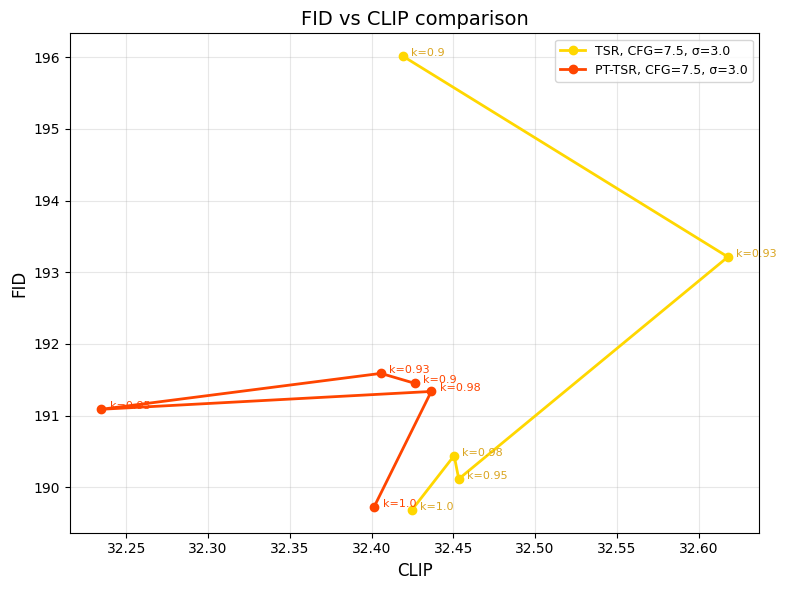

Saved fid_vs_clip.png


In [5]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, PngImagePlugin
from tqdm import tqdm
from transformers import CLIPModel, CLIPProcessor
import cleanfid.fid as fid
from cleanfid.fid import get_folder_features, frechet_distance

# ── Fix PIL ICC profile limit ─────────────────────────────────────────────────
PngImagePlugin.MAX_TEXT_CHUNK = 100 * (1024**2)

# ── Config ────────────────────────────────────────────────────────────────────
REAL_DIR    = "/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/figures/laion_5k_real"
TSR_DIR     = Path("/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/figures/laion_5k_generated")
PT_TSR_DIR  = Path("/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/figures/laion_5k_generated_pt")
PROMPTS_FILE = "laion_5k_prompts.csv"
K_VALUES    = [1.0, 0.98, 0.95, 0.93, 0.9]

df = pd.read_csv(PROMPTS_FILE)
prompts = df["text"].tolist()[:100]

# ── CLIP setup ────────────────────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model     = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# ── FID: precompute real features once ───────────────────────────────────────
print("Computing real image features (one time)...")
feat_model = fid.build_feature_extractor("clean", device=torch.device(device))
real_feats = get_folder_features(REAL_DIR, feat_model, device=torch.device(device))
mu_real    = np.mean(real_feats, axis=0)
sigma_real = np.cov(real_feats, rowvar=False)
print(f"Real features computed from {len(real_feats)} images.\n")

# ── Helpers ───────────────────────────────────────────────────────────────────
def clean_images(gen_dir, prefix):
    """Copy images to tmp dir with ICC profile stripped."""
    gen_dir  = Path(gen_dir)
    tmp_dir  = Path("/tmp/fid_clean") / f"{prefix}_{gen_dir.name}"
    tmp_dir.mkdir(parents=True, exist_ok=True)

    for img_path in gen_dir.glob("*.png"):
        out_path = tmp_dir / img_path.name
        if not out_path.exists():
            try:
                img = Image.open(img_path).convert("RGB")
                img.save(out_path, format="PNG", icc_profile=None)
            except Exception as e:
                print(f"  Warning, skipping {img_path.name}: {e}")

    n = len(list(tmp_dir.glob("*.png")))
    print(f"  [clean] {prefix}_{gen_dir.name}: {n} images")
    return tmp_dir

def compute_fid_score(gen_dir, prefix=""):
    tmp_dir   = clean_images(gen_dir, prefix)
    gen_feats = get_folder_features(str(tmp_dir), feat_model, device=torch.device(device))
    mu_gen    = np.mean(gen_feats, axis=0)
    sigma_gen = np.cov(gen_feats, rowvar=False)
    return frechet_distance(mu_real, sigma_real, mu_gen, sigma_gen)

def compute_clip(gen_dir):
    scores = []
    for idx, prompt in enumerate(tqdm(prompts, desc=f"CLIP {gen_dir.name}")):
        img_path = gen_dir / f"{idx:05d}.png"
        if not img_path.exists():
            continue
        image  = Image.open(img_path).convert("RGB")
        inputs = clip_processor(
            text=[prompt], images=image,
            return_tensors="pt", padding=True,
            truncation=True, max_length=75
        ).to(device)
        with torch.no_grad():
            score = clip_model(**inputs).logits_per_image[0, 0].item()
        scores.append(score)
    return np.mean(scores)

# ── Compute for both TSR and PT-TSR ──────────────────────────────────────────
tsr_results    = {}
pt_tsr_results = {}

for tsr_k in K_VALUES:
    k_str = f"k{tsr_k:.3f}".replace(".", "p")
    print(f"\n── {k_str} ──")

    # TSR
    tsr_gen_dir = TSR_DIR / k_str
    tsr_fid_val  = compute_fid_score(tsr_gen_dir, prefix="tsr")
    tsr_clip_val = compute_clip(tsr_gen_dir)
    tsr_results[tsr_k] = (tsr_fid_val, tsr_clip_val)
    print(f"[TSR]    k={tsr_k:.3f}  FID={tsr_fid_val:.4f}  CLIP={tsr_clip_val:.4f}")

    # PT-TSR
    pt_gen_dir = PT_TSR_DIR / k_str
    pt_fid_val  = compute_fid_score(pt_gen_dir, prefix="pt")
    pt_clip_val = compute_clip(pt_gen_dir)
    pt_tsr_results[tsr_k] = (pt_fid_val, pt_clip_val)
    print(f"[PT-TSR] k={tsr_k:.3f}  FID={pt_fid_val:.4f}  CLIP={pt_clip_val:.4f}")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n── FID (lower is better) ──")
for k in K_VALUES:
    print(f"  k={k:.3f}  TSR={tsr_results[k][0]:.4f}  PT-TSR={pt_tsr_results[k][0]:.4f}")

print("\n── CLIP (higher is better) ──")
for k in K_VALUES:
    print(f"  k={k:.3f}  TSR={tsr_results[k][1]:.4f}  PT-TSR={pt_tsr_results[k][1]:.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

tsr_k_vals    = sorted(tsr_results.keys(), reverse=True)
tsr_clip_vals = [tsr_results[k][1] for k in tsr_k_vals]
tsr_fid_vals  = [tsr_results[k][0] for k in tsr_k_vals]
ax.plot(tsr_clip_vals, tsr_fid_vals, color="gold", marker="o", linewidth=2, label="TSR, CFG=7.5, σ=3.0")
for k in tsr_k_vals:
    f, c = tsr_results[k]
    ax.annotate(f"k={k}", (c, f), textcoords="offset points", xytext=(6, 0), fontsize=8, color="goldenrod")

pt_k_vals    = sorted(pt_tsr_results.keys(), reverse=True)
pt_clip_vals = [pt_tsr_results[k][1] for k in pt_k_vals]
pt_fid_vals  = [pt_tsr_results[k][0] for k in pt_k_vals]
ax.plot(pt_clip_vals, pt_fid_vals, color="orangered", marker="o", linewidth=2, label="PT-TSR, CFG=7.5, σ=3.0")
for k in pt_k_vals:
    f, c = pt_tsr_results[k]
    ax.annotate(f"k={k}", (c, f), textcoords="offset points", xytext=(6, 0), fontsize=8, color="orangered")

ax.set_xlabel("CLIP", fontsize=12)
ax.set_ylabel("FID", fontsize=12)
ax.set_title("FID vs CLIP comparison", fontsize=14)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fid_vs_clip.png", dpi=150)
plt.show()
print("Saved fid_vs_clip.png")